# Xi0 Workflow From Project Modules

Ce notebook utilise directement les modules Python du dossier `code/`.

Objectif :
- choisir un ou plusieurs CSV d'entree,
- assembler les donnees proprement,
- calculer `xi0(t)` avec les fonctions du projet,
- afficher les objets principaux et tracer les courbes.

In [2]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt


def find_project_root(start: Path) -> Path:
    candidates = [start.resolve(), *start.resolve().parents]
    for candidate in candidates:
        if (candidate / "code" / "__init__.py").exists():
            return candidate
        if candidate.name == "code" and (candidate / "__init__.py").exists() and (candidate / "xi0.py").exists():
            return candidate.parent
    raise FileNotFoundError("Could not locate the project root containing the code package.")


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from csv_assembler import assemble_option_chains, discover_csv_files
from xi0 import (
    compute_xi0_from_assembled_data,
    compute_xi0_from_csvs,
    plot_xi0_curves,
    sample_xi0_curves,
)

PROJECT_ROOT

PosixPath('/home/louis.savary/Bureau/PRRE_maison')

## 1. Choix des CSV d'entree

Ajoute ici autant de fichiers que tu veux, a condition qu'ils correspondent a des snapshots pris a la meme date.

In [3]:
INPUT_CSV_FILES = [
    PROJECT_ROOT / "spx_quotedata.csv",
    PROJECT_ROOT / "spx_quotedata_mai.csv",
    PROJECT_ROOT / "spx_quotedata_juin.csv",
]

pd.DataFrame({"input_csv": [str(path) for path in INPUT_CSV_FILES]})

,input_csv
0,/home/louis.savary/Bureau/PRRE_maison/spx_quot...
1,/home/louis.savary/Bureau/PRRE_maison/spx_quot...
2,/home/louis.savary/Bureau/PRRE_maison/spx_quot...


Option pratique : si un jour tu ranges tes CSV dans un dossier dedie, tu pourras aussi utiliser `discover_csv_files(...)`.

In [ ]:
# Exemple facultatif : decouverte automatique des CSV dans un dossier.
# DATA_DIR = PROJECT_ROOT / "data"
# AUTO_CSV_FILES = discover_csv_files(DATA_DIR)
# pd.DataFrame({"auto_csv": [str(path) for path in AUTO_CSV_FILES]})

## 2. Assemblage intelligent des donnees

In [4]:
assembled_data = assemble_option_chains(
    csv_paths=INPUT_CSV_FILES,
    require_same_quote_date=True,
)

summary = pd.DataFrame(
    [
        {"name": "quote_date", "value": str(assembled_data.quote_date.date())},
        {"name": "spot", "value": f"{assembled_data.spot:.4f}"},
        {"name": "n_input_files", "value": len(assembled_data.input_files)},
        {"name": "n_option_rows", "value": len(assembled_data.option_chain)},
        {"name": "duplicates_removed", "value": assembled_data.duplicates_removed},
    ]
)

summary

,name,value
0,quote_date,2026-04-10
1,spot,6827.4250
2,n_input_files,3
3,n_option_rows,198
4,duplicates_removed,0


In [5]:
assembled_data.file_metadata

,source_file,quote_date,spot,spot_last,spot_bid,spot_ask,row_count,min_expiration,max_expiration
0,/home/louis.savary/Bureau/PRRE_maison/spx_quot...,2026-04-10,6827.42505,6827.46,6824.4399,6830.4102,90,2026-04-10,2026-04-30
1,/home/louis.savary/Bureau/PRRE_maison/spx_quot...,2026-04-10,6827.42505,6827.46,6824.4399,6830.4102,18,2026-06-05,2026-06-30
2,/home/louis.savary/Bureau/PRRE_maison/spx_quot...,2026-04-10,6827.42505,6827.46,6824.4399,6830.4102,90,2026-05-01,2026-05-29


In [6]:
assembled_data.option_chain.head(10)

,expiration,call_symbol,call_last,call_net,call_bid,call_ask,call_volume,call_iv,call_delta,call_gamma,...,source_file,source_spot,call_mid,put_mid,call_bid_ask_spread,put_bid_ask_spread,quote_completeness,total_volume,total_open_interest,mean_bid_ask_spread
0,2026-04-10,SPXW260410C06815000,19.90,-10.50,20.7,20.9,867,0.1832,0.6482,0.0115,...,/home/louis.savary/Bureau/PRRE_maison/spx_quot...,6827.42505,20.80,7.30,0.2,0.2,6,5238,2608,0.20
1,2026-04-10,SPXW260410C06820000,17.30,-9.85,17.2,17.3,2251,0.1771,0.5918,0.0124,...,/home/louis.savary/Bureau/PRRE_maison/spx_quot...,6827.42505,17.25,8.80,0.1,0.2,6,10847,4409,0.15
2,2026-04-10,SPXW260410C06825000,13.30,-10.75,14.0,14.2,4558,0.1735,0.5295,0.0129,...,/home/louis.savary/Bureau/PRRE_maison/spx_quot...,6827.42505,14.10,10.65,0.2,0.1,6,13023,5459,0.15
3,2026-04-10,SPXW260410C06830000,11.30,-9.90,11.1,11.3,9392,0.1696,0.4638,0.0132,...,/home/louis.savary/Bureau/PRRE_maison/spx_quot...,6827.42505,11.20,12.80,0.2,0.2,6,22548,4471,0.20
4,2026-04-10,SPXW260410C06835000,8.60,-9.95,8.7,8.9,8764,0.1674,0.3970,0.0130,...,/home/louis.savary/Bureau/PRRE_maison/spx_quot...,6827.42505,8.80,15.30,0.2,0.2,6,13563,1312,0.20
5,2026-04-10,SPXW260410C06840000,6.80,-9.25,6.7,6.8,8909,0.1654,0.3325,0.0124,...,/home/louis.savary/Bureau/PRRE_maison/spx_quot...,6827.42505,6.75,18.30,0.1,0.2,6,12455,3143,0.15
6,2026-04-13,SPXW260413C06815000,36.80,-8.10,37.8,38.1,38,0.1188,0.5682,0.0051,...,/home/louis.savary/Bureau/PRRE_maison/spx_quot...,6827.42505,37.95,23.80,0.3,0.2,6,131,559,0.25
7,2026-04-13,SPXW260413C06820000,32.39,-9.36,34.6,34.9,140,0.1171,0.5430,0.0053,...,/home/louis.savary/Bureau/PRRE_maison/spx_quot...,6827.42505,34.75,25.70,0.3,0.2,6,343,1039,0.25
8,2026-04-13,SPXW260413C06825000,31.40,-7.25,31.6,31.8,634,0.1156,0.5168,0.0054,...,/home/louis.savary/Bureau/PRRE_maison/spx_quot...,6827.42505,31.70,27.60,0.2,0.2,6,879,2592,0.20
9,2026-04-13,SPXW260413C06830000,29.00,-6.70,28.6,28.8,456,0.1140,0.4899,0.0054,...,/home/louis.savary/Bureau/PRRE_maison/spx_quot...,6827.42505,28.70,29.75,0.2,0.3,6,947,2042,0.25


## 3. Calcul de xi0(t) a partir des modules

In [7]:
xi0_result = compute_xi0_from_assembled_data(
    assembled_data=assembled_data,
    include_zero_interval=False,
)

xi0_summary = pd.DataFrame(
    [
        {"name": "n_atm_maturities", "value": len(xi0_result.atm_term_structure)},
        {"name": "n_xi0_intervals", "value": len(xi0_result.xi0_step_curve)},
    ]
)

xi0_summary

,name,value
0,n_atm_maturities,32
1,n_xi0_intervals,31


In [8]:
xi0_result.atm_term_structure

,expiration,ttm_days,ttm_years,strike,call_symbol,put_symbol,source_file,call_iv,put_iv,atm_iv,total_variance,distance_to_spot,total_open_interest,total_volume
0,2026-04-13,3.0,0.008219,6825.0,SPXW260413C06825000,SPXW260413P06825000,/home/louis.savary/Bureau/PRRE_maison/spx_quot...,0.1156,0.1150,0.11530,0.000109,2.42505,2592,879
1,2026-04-14,4.0,0.010959,6825.0,SPXW260414C06825000,SPXW260414P06825000,/home/louis.savary/Bureau/PRRE_maison/spx_quot...,0.1248,0.1250,0.12490,0.000171,2.42505,955,263
2,2026-04-15,5.0,0.013699,6825.0,SPXW260415C06825000,SPXW260415P06825000,/home/louis.savary/Bureau/PRRE_maison/spx_quot...,0.1324,0.1321,0.13225,0.000240,2.42505,1230,70
3,2026-04-16,6.0,0.016438,6825.0,SPXW260416C06825000,SPXW260416P06825000,/home/louis.savary/Bureau/PRRE_maison/spx_quot...,0.1375,0.1372,0.13735,0.000310,2.42505,1129,24
4,2026-04-17,7.0,0.019178,6825.0,SPX260417C06825000,SPX260417P06825000,/home/louis.savary/Bureau/PRRE_maison/spx_quot...,0.1389,0.1388,0.13885,0.000370,2.42505,4986,258
5,2026-04-20,10.0,0.027397,6825.0,SPXW260420C06825000,SPXW260420P06825000,/home/louis.savary/Bureau/PRRE_maison/spx_quot...,0.1372,0.1371,0.13715,0.000515,2.42505,549,14
6,2026-04-21,11.0,0.030137,6825.0,SPXW260421C06825000,SPXW260421P06825000,/home/louis.savary/Bureau/PRRE_maison/spx_quot...,0.1405,0.1403,0.14040,0.000594,2.42505,279,16
7,2026-04-22,12.0,0.032877,6825.0,SPXW260422C06825000,SPXW260422P06825000,/home/louis.savary/Bureau/PRRE_maison/spx_quot...,0.1439,0.1438,0.14385,0.000680,2.42505,481,8
8,2026-04-23,13.0,0.035616,6825.0,SPXW260423C06825000,SPXW260423P06825000,/home/louis.savary/Bureau/PRRE_maison/spx_quot...,0.1464,0.1462,0.14630,0.000762,2.42505,330,12
9,2026-04-24,14.0,0.038356,6825.0,SPXW260424C06825000,SPXW260424P06825000,/home/louis.savary/Bureau/PRRE_maison/spx_quot...,0.1493,0.1492,0.14925,0.000854,2.42505,1284,54


In [9]:
xi0_result.xi0_step_curve

,expiration,t_left_years,t_right_years,xi0,t_mid_years,t_left_days,t_right_days,t_mid_days
0,2026-04-14,0.008219,0.010959,0.022518,0.009589,3.0,4.0,3.5
1,2026-04-15,0.010959,0.013699,0.025050,0.012329,4.0,5.0,4.5
2,2026-04-16,0.013699,0.016438,0.025740,0.015068,5.0,6.0,5.5
3,2026-04-17,0.016438,0.019178,0.021765,0.017808,6.0,7.0,6.5
4,2026-04-20,0.019178,0.027397,0.017715,0.023288,7.0,10.0,8.5
5,2026-04-21,0.027397,0.030137,0.028733,0.028767,10.0,11.0,10.5
6,2026-04-22,0.030137,0.032877,0.031480,0.031507,11.0,12.0,11.5
7,2026-04-23,0.032877,0.035616,0.029934,0.034247,12.0,13.0,12.5
8,2026-04-24,0.035616,0.038356,0.033610,0.036986,13.0,14.0,13.5
9,2026-04-27,0.038356,0.046575,0.015518,0.042466,14.0,17.0,15.5


## 4. Evaluation numerique de xi0(t)

In [10]:
sample_xi0_curves(
    xi0_result=xi0_result,
    sample_days=[7, 10, 14, 20, 30],
)

,t_days,t_years,xi0_step,xi0_smooth
0,7.0,0.019178,0.017715,0.020349
1,10.0,0.027397,0.028733,0.026017
2,14.0,0.038356,0.015518,0.030783
3,20.0,0.054795,0.037859,0.044700
4,30.0,0.082192,0.013215,0.017169


## 5. Plot de xi0(t)

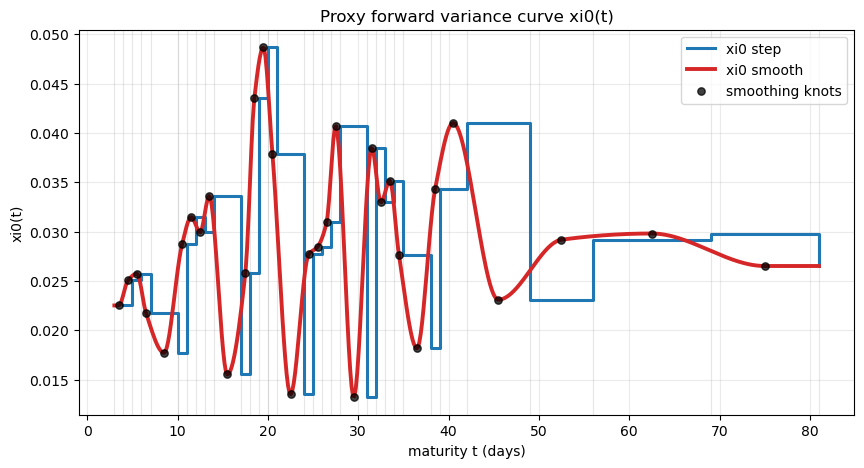

In [11]:
ax = plot_xi0_curves(
    xi0_result=xi0_result,
    use_days=True,
)
plt.show()

## 6. Variante compacte en une seule ligne

Si tu veux aller vite dans un autre notebook, tu peux aussi appeler directement la fonction haut niveau `compute_xi0_from_csvs(...)`.

In [12]:
quick_result = compute_xi0_from_csvs(INPUT_CSV_FILES)
quick_result.xi0_step_curve.head()

,expiration,t_left_years,t_right_years,xi0,t_mid_years,t_left_days,t_right_days,t_mid_days
0,2026-04-14,0.008219,0.010959,0.022518,0.009589,3.0,4.0,3.5
1,2026-04-15,0.010959,0.013699,0.025050,0.012329,4.0,5.0,4.5
2,2026-04-16,0.013699,0.016438,0.025740,0.015068,5.0,6.0,5.5
3,2026-04-17,0.016438,0.019178,0.021765,0.017808,6.0,7.0,6.5
4,2026-04-20,0.019178,0.027397,0.017715,0.023288,7.0,10.0,8.5
